# Import libs and read data

In [1]:
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import os, json


from  Strong_hierarchical_lasso.SHIM import *


# --- Specify number of levels for each factor ---
l1, l2, l3, l4 = 21, 14, 2, 3
levels_list=[l1,l2,l3,l4]
# Get ranges
ranges = get_ranges4(l1=l1, l2=l2, l3=l3, l4=l4)
range_main, range_theta, range_psi, range_phi = ranges


#Load data

base_path = "../../Data/Data_Buchwald_Hartwig_amination"
filename_xtrain = "xtrain.csv.gz"
filename_xtest = "xtest.csv.gz"
filename_xall = "xxxxall.csv.gz"
filename_ytrain = "ytrain.csv"
filename_ytest = "ytest.csv"
filename_yall = "yall.csv"
filename_names_main="main_names.json"
filename_names_levels="main_levels.json"

X_train = pd.read_csv(os.path.join(base_path,filename_xtrain),  compression="gzip").to_numpy()
X_test = pd.read_csv(os.path.join(base_path,filename_xtest),  compression="gzip").to_numpy()
X_all = pd.read_csv(os.path.join(base_path,filename_xall),  compression="gzip").to_numpy()
y_train = pd.read_csv(os.path.join(base_path,filename_ytrain)).to_numpy().ravel()  
y_test = pd.read_csv(os.path.join(base_path,filename_ytest)).to_numpy().ravel()
y_all = pd.read_csv(os.path.join(base_path,filename_yall)).to_numpy().ravel()
with open(os.path.join(base_path,filename_names_main), "r") as file:
    main_names = json.load(file)
    







# Train with AIC params on full data and estimate all coefficients

 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 4;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 5;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 6;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
 Start iteration: 7;
Updated intercept
Updated beta
Updated gamma
Updated delta
Four ways are 0.
The model has converged.
R² score: 0.8780867339829339


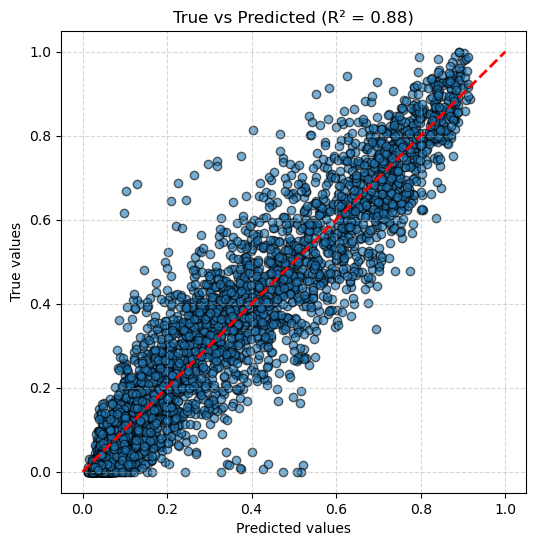

0.8780867339829339

In [2]:
shim = SHIM(X=X_all,
            y=y_all,
            init_list=None,
            levels_list=levels_list,
            lambdas_list=[5e-5, 7e-4, 1e-3, 3e-3],
            max_iter=10,
            use_init_main = True,
            use_init_main_w= True,
            w_list=None
        )

shim_fitted = shim.fit_model()
shim_fitted.R2_score(X_all, y_all, plot=True)
#print(shim_fitted.model.beta_hat)
#print(shim_fitted.model.gamma_hat)
#print(shim_fitted.model.delta_hat)

# Save the coefficients and show how to load them

In [3]:

beta_all_shim=shim_fitted.model.beta_all
intercept_all=shim_fitted.model.intercept

print(f"Number of non-zeros in fitted coefficients  is: {sum(beta_all_shim!=0)+1} out of {len(beta_all_shim)+1} coefficients.")

coefs_all = np.concatenate(([intercept_all], beta_all_shim))

    
recovered_coefs=recover_coefs_with_names(main_names=main_names, beta= beta_all_shim, intercept=intercept_all, levels=levels_list)
print(f"Number of non-zeros in recovered coefficients  is: {sum(recovered_coefs["Values"].values!=0)+1} out of {len(recovered_coefs["Values"].values)} coefficients.")





recovered_coefs.to_excel("Final_coefficients_Buchwald_Harwtig amination.xlsx")
print("The final coefficients are saved in Analysis_Buchwald_Hartwig_amination.")



Number of non-zeros in fitted coefficients  is: 278 out of 3960 coefficients.
Number of non-zeros in recovered coefficients  is: 415 out of 7360 coefficients.
The final coefficients are saved in Analysis_Buchwald_Hartwig_amination.
